<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enhanced SleepStageNet: Improved CNN, LSTM & Conformer for Sleep Stage Classification

**CSEP 590A Deep Learning — Group Project**

This notebook trains and evaluates **3 model architectures** for automatic sleep stage classification on the Sleep-EDF dataset:

| # | Model | Architecture | Key innovation |
|---|-------|-------------|----------------|
| 1 | `cnn_only` | Multi-scale CNN | Dual-path (fine + coarse filters) — improved baseline |
| 2 | `cnn_bilstm` | CNN + BiLSTM | Enhanced multi-scale CNN backbone, deeper LSTM |
| 3 | `conformer` | CNN + Conformer blocks | Attention + depthwise conv — best of both worlds |

### Improvements over baseline
- **Multi-scale CNN** backbone inspired by DeepSleepNet-Lite (small + large filter paths)
- **Focal loss** for handling severe N1 class imbalance
- **Label smoothing** + **Mixup augmentation** for regularization
- **Cosine annealing with warmup** for stable training
- **EEG data augmentation** (time shift, amplitude scaling, Gaussian noise)
- **3-stage training**: pretrain CNN → train temporal layers → fine-tune end-to-end

### HuggingFace models survey
We surveyed HuggingFace for pretrained EEG/sleep staging models. Current options are limited:
- `karnamgyal/sleep-stage-classifier` — CNN-LSTM, ~73% accuracy (lower than our baseline)
- `haseebnawazz/sleep-stage-classifier-model` — sklearn/joblib model, not deep learning
- `Soromis/BP-transformer-EEG` — Transformer for EEG, but for blood pressure estimation

The field primarily uses custom architectures: **SleepTransformer** (Phan et al., 2022), **L-SeqSleepNet** (Phan et al., 2023), **U-Sleep** (Perslev et al., 2021). Our Conformer model draws inspiration from these papers.

### Drive integration
All outputs (checkpoints, figures, results, training curves) are automatically saved to Google Drive.

**Runtime:** Select **GPU** (T4 or better) via `Runtime > Change runtime type`.

## 1. Environment Setup

In [1]:
# ===== 1a: Install dependencies & check GPU =====
!pip install -q torch torchvision torchaudio scikit-learn scipy matplotlib seaborn gdown

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected — training will be very slow. Go to Runtime > Change runtime type > GPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# ===== 1b: Mount Google Drive & set paths =====
import os, shutil
from google.colab import drive

drive.mount('/content/drive')

# ── Configure paths ──────────────────────────────────────────────
# This is the shared Google Drive folder that contains data/ already.
# Folder ID: 1S-RIIPcetbevDHsgY6hutbXkAKefsV5C
# Update DRIVE_BASE if your folder is mounted at a different path.
DRIVE_BASE = '/content/drive/MyDrive/SleepStageNet'

# Verify the folder exists
assert os.path.isdir(DRIVE_BASE), (
    f"Drive folder not found at {DRIVE_BASE}.\n"
    "Open the shared folder link in your browser, right-click > 'Add shortcut to Drive' > 'My Drive',\n"
    "then update DRIVE_BASE above to match the mounted path."
)

# Data paths (already on Drive)
DRIVE_DATA_DIR   = os.path.join(DRIVE_BASE, 'data', 'eeg_FpzCz_PzOz_v1')
DRIVE_SPLIT_PATH = os.path.join(DRIVE_BASE, 'data', 'data_split_v1.npz')

assert os.path.isdir(DRIVE_DATA_DIR), f"Data dir not found: {DRIVE_DATA_DIR}"
assert os.path.isfile(DRIVE_SPLIT_PATH), f"Split file not found: {DRIVE_SPLIT_PATH}"

# Output folder on Drive — everything gets saved here
DRIVE_ENHANCED = os.path.join(DRIVE_BASE, 'enhanced')
DRIVE_CKPT_DIR   = os.path.join(DRIVE_ENHANCED, 'checkpoints')
DRIVE_FIG_DIR    = os.path.join(DRIVE_ENHANCED, 'figures')
DRIVE_RESULT_DIR = os.path.join(DRIVE_ENHANCED, 'results')
DRIVE_CURVE_DIR  = os.path.join(DRIVE_ENHANCED, 'training_curves')

for d in [DRIVE_CKPT_DIR, DRIVE_FIG_DIR, DRIVE_RESULT_DIR, DRIVE_CURVE_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Drive base:   {DRIVE_BASE}")
print(f"Data dir:     {DRIVE_DATA_DIR}  ({len(os.listdir(DRIVE_DATA_DIR))} files)")
print(f"Split file:   {DRIVE_SPLIT_PATH}")
print(f"Enhanced out: {DRIVE_ENHANCED}")
print("✓ Drive mounted and paths verified.")

Mounted at /content/drive
Drive base:   /content/drive/MyDrive/SleepStageNet
Data dir:     /content/drive/MyDrive/SleepStageNet/data/eeg_FpzCz_PzOz_v1  (39 files)
Split file:   /content/drive/MyDrive/SleepStageNet/data/data_split_v1.npz
Enhanced out: /content/drive/MyDrive/SleepStageNet/enhanced
✓ Drive mounted and paths verified.


## 2. Code & Data Setup

Source code (`models.py`, `data_loader.py`, `train.py`) is read directly from Drive.  
Data is **copied** from Drive to the local Colab runtime for faster I/O during training.

In [3]:
# ===== 2a: Set up source code & copy data to local runtime =====
import os, shutil, glob, sys

# ── Source code: use enhanced/ directly from Drive ──
# The 3 Python files (models.py, data_loader.py, train.py) live on Drive
# under DRIVE_BASE/enhanced/. We create a local working copy.
DRIVE_CODE_DIR = os.path.join(DRIVE_BASE, 'enhanced')
LOCAL_WORK_DIR = '/content/enhanced'

os.makedirs(LOCAL_WORK_DIR, exist_ok=True)
for src_file in ['models.py', 'data_loader.py', 'train.py']:
    src = os.path.join(DRIVE_CODE_DIR, src_file)
    dst = os.path.join(LOCAL_WORK_DIR, src_file)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"  Copied {src_file}")
    else:
        print(f"  ⚠️  {src_file} not found at {src}")

# ── Copy data from Drive to local runtime for faster I/O ──
LOCAL_DATA_DIR  = '/content/data/eeg_FpzCz_PzOz_v1'
LOCAL_SPLIT_PATH = '/content/data/data_split_v1.npz'

if not os.path.isdir(LOCAL_DATA_DIR):
    print("\nCopying data from Drive to local runtime (faster I/O)...")
    os.makedirs(os.path.dirname(LOCAL_DATA_DIR), exist_ok=True)
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    shutil.copy2(DRIVE_SPLIT_PATH, LOCAL_SPLIT_PATH)
    print("Data copied.")
else:
    print("\nLocal data already exists.")

npz_files = sorted(glob.glob(os.path.join(LOCAL_DATA_DIR, '*.npz')))
print(f"Data: {len(npz_files)} .npz files")

# ── Set environment variables & working directory ──
DATA_DIR_ABS   = os.path.abspath(LOCAL_DATA_DIR)
SPLIT_PATH_ABS = os.path.abspath(LOCAL_SPLIT_PATH)
os.environ['SLEEP_DATA_DIR']   = DATA_DIR_ABS
os.environ['SLEEP_SPLIT_PATH'] = SPLIT_PATH_ABS

os.chdir(LOCAL_WORK_DIR)
sys.path.insert(0, LOCAL_WORK_DIR)

print(f"\nDATA_DIR_ABS:   {DATA_DIR_ABS}")
print(f"SPLIT_PATH_ABS: {SPLIT_PATH_ABS}")
print(f"Working dir:    {os.getcwd()}")
!ls -la

  Copied models.py
  Copied data_loader.py
  Copied train.py

Copying data from Drive to local runtime (faster I/O)...
Data copied.
Data: 39 .npz files

DATA_DIR_ABS:   /content/data/eeg_FpzCz_PzOz_v1
SPLIT_PATH_ABS: /content/data/data_split_v1.npz
Working dir:    /content/enhanced
total 72
drwxr-xr-x 2 root root  4096 Mar  8 17:14 .
drwxr-xr-x 1 root root  4096 Mar  8 17:14 ..
-rw------- 1 root root 12076 Mar  8 06:46 data_loader.py
-rw------- 1 root root 27130 Mar  8 06:33 models.py
-rw------- 1 root root 24124 Mar  8 06:21 train.py


Number of .npz files: 39
Sample: x=(841, 3000, 2), y=(841,), fs=100.0 Hz


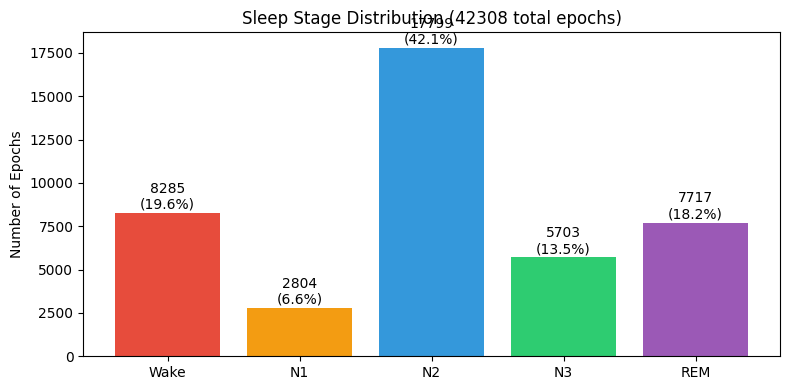


Class imbalance ratio (max/min): 6.3x
N1 is only 6.6% — motivates focal loss
Figure saved to Drive: /content/drive/MyDrive/SleepStageNet/enhanced/figures/class_distribution.png


In [4]:
# ===== 2b: Data sanity check + class distribution =====
import numpy as np
import matplotlib.pyplot as plt

data_files = sorted([f for f in os.listdir(DATA_DIR_ABS) if f.endswith('.npz')])
print(f"Number of .npz files: {len(data_files)}")

# Load and inspect one file
sample_file = os.path.join(DATA_DIR_ABS, data_files[0])
with np.load(sample_file) as f:
    x = f['x']; y = f['y']; fs = f['fs']
print(f"Sample: x={x.shape}, y={y.shape}, fs={fs} Hz")

# Class distribution
all_labels = np.concatenate([np.load(os.path.join(DATA_DIR_ABS, f))['y'] for f in data_files])
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
counts = [np.sum(all_labels == i) for i in range(5)]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
bars = ax.bar(stage_names, counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count}\n({100*count/len(all_labels):.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of Epochs')
ax.set_title(f'Sleep Stage Distribution ({len(all_labels)} total epochs)')
plt.tight_layout()

# Save to Drive
fig.savefig(os.path.join(DRIVE_FIG_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio (max/min): {max(counts)/min(counts):.1f}x")
print(f"N1 is only {100*counts[1]/sum(counts):.1f}% — motivates focal loss")
print(f"Figure saved to Drive: {DRIVE_FIG_DIR}/class_distribution.png")

## 3. Model Architectures Overview

Let's inspect the available models and their parameter counts.

In [5]:
# ===== 3: Model architectures & parameter counts =====
import sys, torch
sys.path.insert(0, '.')

from models import MODEL_REGISTRY, MODEL_CONFIGS, build_model

print(f"{'Model':<20s} {'Params':>10s} {'Seq Len':>8s} {'Batch':>6s} {'Output':>12s}")
print('-' * 60)

B, L, C, T = 2, 11, 2, 3000
x_seq = torch.randn(B, L, C, T)
x_single = torch.randn(B, C, T)

for name in MODEL_REGISTRY:
    config = MODEL_CONFIGS[name]
    model = build_model(name, **config['model_kwargs'])
    n_params = sum(p.numel() for p in model.parameters())

    if name == 'cnn_only':
        out = model(x_single)
    else:
        out = model(x_seq)

    print(f'{name:<20s} {n_params:>10,} {config["seq_length"]:>8d} '
          f'{config["batch_size"]:>6d} {str(list(out.shape)):>12s}')
    del model

print(f'\nFor comparison: DeepSleepNet-Lite baseline has ~648K params')
print(f'                CNN+BiLSTM (temporal/) has ~345K params')

Model                    Params  Seq Len  Batch       Output
------------------------------------------------------------
cnn_only                190,661        1     64       [2, 5]
cnn_bilstm              850,757       11     32       [2, 5]
conformer             1,338,821       11     32       [2, 5]

For comparison: DeepSleepNet-Lite baseline has ~648K params
                CNN+BiLSTM (temporal/) has ~345K params


## 4. Training

### Training strategy
**3-stage training** for sequence models:
1. **CNN pre-training** on individual epochs (~50 epochs) — warm up the feature extractor
2. **Temporal training** with CNN frozen (~50 epochs) — train attention/LSTM on features
3. **End-to-end fine-tuning** with low LR (~30 epochs) — tune entire model jointly

### Key hyperparameter choices
| Parameter | Baseline (temporal/) | Enhanced |
|-----------|---------------------|----------|
| CNN | Single-path, 64-dim | **Multi-scale dual-path, 128-dim** |
| Seq length | 5 | **11-21** (more context) |
| Loss | CrossEntropy | **Focal Loss** (γ=2) + label smoothing |
| Augmentation | None | **Time shift, amplitude scale, noise, Mixup** |
| LR schedule | ReduceLROnPlateau | **Cosine annealing + warmup** |
| LSTM layers | 1 | **2** (for BiLSTM variants) |
| Dropout | 0.3 | **0.2-0.3** + residual dropout |

In [ ]:
# ===== Cell 4a: Quick test — train fold 0 of ONE model =====
# Change MODEL_NAME to test different architectures.
# Takes ~5-15 min on T4 depending on model.

MODEL_NAME = "conformer"  # Options: cnn_only, cnn_bilstm, conformer

!python train.py \
    --model {MODEL_NAME} \
    --fold 0 \
    --data_dir {DATA_DIR_ABS} \
    --split_path {SPLIT_PATH_ABS} \
    --cnn_epochs 30 \
    --temporal_epochs 30 \
    --finetune_epochs 20 \
    --output_dir output \
    --drive_ckpt_dir {DRIVE_CKPT_DIR}

print(f"\n✓ Checkpoint auto-saved to Drive after training.")


Fold 0 | model=conformer | seq_len=11 | device=cuda
batch_size=32 | lr=0.0003 | epochs=80 | focal=True | mixup=0.1

[1] Loading data...
  Train: 37701 | Val: 2269 | Test: 1948
  Class weights: [1.041 3.033 0.473 1.513 1.072]

[2] Stage 1: Pre-training CNN on individual epochs...
  [CNN pretrain] ep   1/30: loss=0.5248 acc=0.683 f1=0.652 | val loss=0.4037 acc=0.799 f1=0.761 κ=0.717 lr=1.0e-03 (13.6s) *
  [CNN pretrain] ep   5/30: loss=0.3881 acc=0.770 f1=0.740 | val loss=0.4955 acc=0.686 f1=0.686 κ=0.585 lr=1.0e-03 (11.6s)
  [CNN pretrain] ep   6/30: loss=0.3766 acc=0.773 f1=0.744 | val loss=0.3497 acc=0.823 f1=0.769 κ=0.739 lr=1.0e-03 (11.3s) *
  [CNN pretrain] ep  10/30: loss=0.3457 acc=0.789 f1=0.762 | val loss=0.3481 acc=0.822 f1=0.796 κ=0.748 lr=1.0e-03 (14.6s) *
  [CNN pretrain] ep  15/30: loss=0.3082 acc=0.809 f1=0.783 | val loss=0.3664 acc=0.768 f1=0.756 κ=0.680 lr=1.0e-03 (18.1s)
  [CNN pretrain] ep  20/30: loss=0.2450 acc=0.842 f1=0.823 | val loss=0.4059 acc=0.769 f1=0.749 κ=

In [ ]:
# ===== Cell 4b: Train all 3 models on fold 0 for comparison =====
# ~20-40 min total on T4 GPU
# Each model's checkpoint is auto-uploaded to Drive via --drive_ckpt_dir

import os

MODELS_TO_TRAIN = ['cnn_only', 'cnn_bilstm', 'conformer']

for model_name in MODELS_TO_TRAIN:
    ckpt_dir = f'output/{model_name}'
    existing = [f for f in os.listdir(ckpt_dir)
                if f.startswith(f'{model_name}_fold0') or f.startswith('results_fold0')
                ] if os.path.isdir(ckpt_dir) else []
    if existing:
        print(f"\n{'='*60}")
        print(f"{model_name}: fold 0 already trained — skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    !python train.py \
        --model {model_name} \
        --fold 0 \
        --data_dir {DATA_DIR_ABS} \
        --split_path {SPLIT_PATH_ABS} \
        --output_dir output \
        --drive_ckpt_dir {DRIVE_CKPT_DIR}

print("\n✓ All 3 models trained on fold 0 & auto-saved to Drive!")


cnn_only: fold 0 already trained — skipping.

Training: cnn_bilstm

Fold 0 | model=cnn_bilstm | seq_len=11 | device=cuda
batch_size=32 | lr=0.0005 | epochs=60 | focal=False | mixup=0.1

[1] Loading data...
  Train: 37701 | Val: 2269 | Test: 1948
  Class weights: [1.041 3.033 0.473 1.513 1.072]

[2] Stage 1: Pre-training CNN on individual epochs...
  [CNN pretrain] ep   1/50: loss=0.8915 acc=0.735 f1=0.687 | val loss=0.7747 acc=0.861 f1=0.806 κ=0.793 lr=1.0e-03 (12.3s) *
  [CNN pretrain] ep   3/50: loss=0.7764 acc=0.802 f1=0.754 | val loss=0.7262 acc=0.857 f1=0.809 κ=0.792 lr=1.0e-03 (11.9s) *
  [CNN pretrain] ep   4/50: loss=0.7575 acc=0.809 f1=0.763 | val loss=0.7342 acc=0.867 f1=0.820 κ=0.805 lr=1.0e-03 (11.7s) *
  [CNN pretrain] ep   5/50: loss=0.7425 acc=0.815 f1=0.771 | val loss=0.7362 acc=0.843 f1=0.799 κ=0.773 lr=1.0e-03 (11.8s)
  [CNN pretrain] ep  10/50: loss=0.6821 acc=0.836 f1=0.798 | val loss=0.8158 acc=0.762 f1=0.745 κ=0.675 lr=1.0e-03 (11.6s)
  [CNN pretrain] ep  12/50: 

In [ ]:
# ===== Cell 4c: Full 20-fold CV for the best model =====
# Takes ~2-4 hours on T4.
# Checkpoints are auto-uploaded to Drive AFTER EACH FOLD (crash-resilient).

import os

BEST_MODEL = "conformer"  # Change after comparing fold 0 results

!python train.py \
    --model {BEST_MODEL} \
    --all_folds \
    --data_dir {DATA_DIR_ABS} \
    --split_path {SPLIT_PATH_ABS} \
    --output_dir output \
    --drive_ckpt_dir {DRIVE_CKPT_DIR}

print(f"\n✓ All 20-fold checkpoints for {BEST_MODEL} saved to Drive: {DRIVE_CKPT_DIR}/{BEST_MODEL}")


Fold 0 | model=conformer | seq_len=11 | device=cuda
batch_size=32 | lr=0.0003 | epochs=80 | focal=True | mixup=0.1

[1] Loading data...
  Train: 37701 | Val: 2269 | Test: 1948
  Class weights: [1.041 3.033 0.473 1.513 1.072]

[2] Stage 1: Pre-training CNN on individual epochs...
  [CNN pretrain] ep   1/50: loss=0.5253 acc=0.686 f1=0.652 | val loss=0.3725 acc=0.839 f1=0.795 κ=0.768 lr=1.0e-03 (12.9s) *
  [CNN pretrain] ep   5/50: loss=0.3914 acc=0.769 f1=0.738 | val loss=0.3083 acc=0.758 f1=0.754 κ=0.671 lr=1.0e-03 (12.6s)
  [CNN pretrain] ep  10/50: loss=0.3178 acc=0.804 f1=0.777 | val loss=0.4284 acc=0.785 f1=0.757 κ=0.700 lr=5.0e-04 (12.2s)
  [CNN pretrain] ep  15/50: loss=0.2717 acc=0.827 f1=0.804 | val loss=0.3996 acc=0.796 f1=0.754 κ=0.714 lr=5.0e-04 (12.2s)
  [CNN pretrain] ep  16/50: loss=0.2660 acc=0.827 f1=0.805 | val loss=0.3389 acc=0.830 f1=0.796 κ=0.758 lr=5.0e-04 (12.0s) *
  [CNN pretrain] ep  20/50: loss=0.2445 acc=0.841 f1=0.822 | val loss=0.3978 acc=0.748 f1=0.740 κ=0.

In [6]:
# ===== Cell 4d: Full 20-fold CV for the best model =====
# Takes ~2-4 hours on T4.
# Checkpoints are auto-uploaded to Drive AFTER EACH FOLD (crash-resilient).

import os

BEST_MODEL = "cnn_bilstm"  # Change after comparing fold 0 results

!python train.py \
    --model {BEST_MODEL} \
    --all_folds \
    --data_dir {DATA_DIR_ABS} \
    --split_path {SPLIT_PATH_ABS} \
    --output_dir output \
    --drive_ckpt_dir {DRIVE_CKPT_DIR}

print(f"\n✓ All 20-fold checkpoints for {BEST_MODEL} saved to Drive: {DRIVE_CKPT_DIR}/{BEST_MODEL}")


Fold 0 | model=cnn_bilstm | seq_len=11 | device=cuda
batch_size=32 | lr=0.0005 | epochs=60 | focal=False | mixup=0.1

[1] Loading data...
  Train: 37701 | Val: 2269 | Test: 1948
  Class weights: [1.041 3.033 0.473 1.513 1.072]

[2] Stage 1: Pre-training CNN on individual epochs...
  [CNN pretrain] ep   1/50: loss=0.8957 acc=0.736 f1=0.683 | val loss=0.8472 acc=0.782 f1=0.753 κ=0.694 lr=1.0e-03 (13.3s) *
  [CNN pretrain] ep   2/50: loss=0.7960 acc=0.794 f1=0.745 | val loss=0.8409 acc=0.820 f1=0.780 κ=0.741 lr=1.0e-03 (11.4s) *
  [CNN pretrain] ep   3/50: loss=0.7731 acc=0.799 f1=0.752 | val loss=0.7616 acc=0.842 f1=0.801 κ=0.771 lr=1.0e-03 (10.9s) *
  [CNN pretrain] ep   5/50: loss=0.7365 acc=0.818 f1=0.774 | val loss=0.7742 acc=0.817 f1=0.780 κ=0.741 lr=1.0e-03 (11.3s)
  [CNN pretrain] ep   7/50: loss=0.7122 acc=0.825 f1=0.783 | val loss=0.7105 acc=0.859 f1=0.821 κ=0.793 lr=1.0e-03 (11.3s) *
  [CNN pretrain] ep  10/50: loss=0.6811 acc=0.836 f1=0.798 | val loss=0.7639 acc=0.845 f1=0.79